In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import fashion_mnist

In [15]:
# Load the Fashion MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [16]:
# Check the shape of the full training data
X_train_full.shape

(60000, 28, 28)

In [17]:
# Check the data type of the full training data
X_train_full.dtype

dtype('uint8')

In [18]:
# Split the full training data into training and validation sets, and normalize pixel values
X_train = X_train_full[5000:] / 255.0
X_valid = X_train_full[:5000] / 255.0
y_valid = y_train_full[:5000]
y_train = y_train_full[5000:]

In [19]:
# Define class names for the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [20]:
# Display the class name for the first training example
class_names[y_train[0]]

'Coat'

In [21]:
# Define the Keras Sequential model architecture
model = Sequential([
    Flatten(input_shape=[28, 28]), # Flatten the 28x28 image into a 1D array
    Dense(300, activation='relu'), # First hidden layer with 300 neurons and ReLU activation
    Dense(100, activation='relu'), # Second hidden layer with 100 neurons and ReLU activation
    Dense(10, activation='softmax') # Output layer with 10 neurons (for 10 classes) and softmax activation
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
# Compile the model
model.compile(
    loss='sparse_categorical_crossentropy', # Loss function for integer labels
    optimizer='sgd', # Stochastic Gradient Descent optimizer
    metrics=['accuracy'] # Metric to monitor during training
)

In [23]:
# Train the model using the training and validation data
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=30 # Number of training epochs
)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7634 - loss: 0.7235 - val_accuracy: 0.8324 - val_loss: 0.5140
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8297 - loss: 0.4908 - val_accuracy: 0.8502 - val_loss: 0.4458
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8448 - loss: 0.4429 - val_accuracy: 0.8512 - val_loss: 0.4313
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8540 - loss: 0.4155 - val_accuracy: 0.8622 - val_loss: 0.3965
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8622 - loss: 0.3951 - val_accuracy: 0.8684 - val_loss: 0.3795
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8671 - loss: 0.3796 - val_accuracy: 0.8682 - val_loss: 0.3792
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8712 - loss: 0.3672 - val_accuracy: 0.8664 - val_loss: 0.3732
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8747 - loss: 0.3552 -

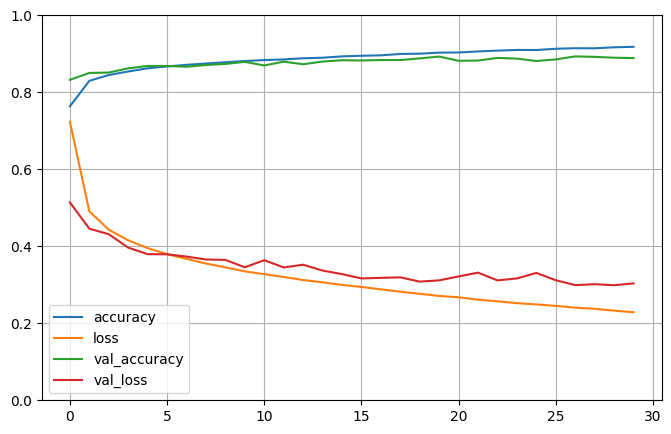

In [24]:
# Plot the training and validation loss/accuracy history
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # Set y-axis limits for better visualization
plt.show()

In [25]:
# Evaluate the model on the test dataset
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8445 - loss: 63.1968


[63.19684982299805, 0.8445000052452087]

In [26]:
# Select the first 3 images from the test set for prediction
X_new = X_test[:3]
# Make predictions on the new images
y_prob = model.predict(X_new)
# Round the probabilities to 2 decimal places for readability
y_prob.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [28]:
# Get the probability distributions for the new images
y_prob = model.predict(X_new)
# Get the predicted class indices by taking the argmax of the probabilities
y_pred = np.argmax(y_prob, axis=-1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([9, 2, 1])

In [30]:
# Get class name for corresponding predicted point
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')